# Foundations of Object Detection: Bounding Boxes, IoU, and NMS

Before training YOLO, it is important to understand the core building blocks of object detection.  
This notebook introduces bounding box representations, Intersection over Union (IoU), and Non-Max Suppression (NMS), which are essential for interpreting how YOLO predicts and filters objects in images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Bounding Boxes

A bounding box is a rectangle used to localize an object in an image.  
In object detection, the model must not only classify the object, but also predict where it is located.

Common formats:
- `(x_min, y_min, x_max, y_max)`
- `(x_center, y_center, width, height)`

The first format is often easier for geometric calculations.  
The second format is commonly used in YOLO annotations.

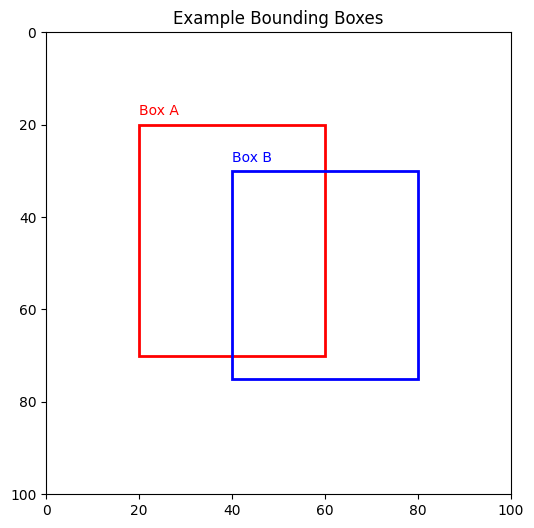

In [2]:
def draw_box(ax, box, color='red', label=None):
    x_min, y_min, x_max, y_max = box
    width = x_max - x_min
    height = y_max - y_min
    
    rect = patches.Rectangle(
        (x_min, y_min), width, height,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    
    if label:
        ax.text(x_min, y_min - 2, label, color=color, fontsize=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 100)
ax.set_ylim(100, 0)
ax.set_title("Example Bounding Boxes")

draw_box(ax, (20, 20, 60, 70), color='red', label='Box A')
draw_box(ax, (40, 30, 80, 75), color='blue', label='Box B')

plt.show()

## Intersection over Union (IoU)

IoU measures how much two bounding boxes overlap.

It is defined as:

IoU = Intersection Area / Union Area

- IoU = 0 means no overlap
- IoU = 1 means perfect overlap

IoU is widely used to evaluate how close a predicted box is to the ground-truth box.

In [3]:
def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_width = max(0, inter_x_max - inter_x_min)
    inter_height = max(0, inter_y_max - inter_y_min)
    inter_area = inter_width * inter_height

    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)

    union_area = area1 + area2 - inter_area

    if union_area == 0:
        return 0.0

    return inter_area / union_area

box_a = (20, 20, 60, 70)
box_b = (40, 30, 80, 75)

iou = compute_iou(box_a, box_b)
print("IoU:", round(iou, 4))

IoU: 0.2667


## Why Non-Max Suppression (NMS) is Needed

Object detectors often produce multiple overlapping boxes for the same object.  
For example, a model may predict several boxes around one pothole, each with a different confidence score.

NMS removes redundant boxes by:
1. keeping the box with the highest confidence
2. removing other boxes that overlap too much with it
3. repeating the process for the remaining boxes

In [4]:
def nms(boxes, scores, iou_threshold=0.5):
    boxes = np.array(boxes)
    scores = np.array(scores)

    order = scores.argsort()[::-1]
    keep = []

    while len(order) > 0:
        current = order[0]
        keep.append(current)

        remaining = []
        for idx in order[1:]:
            iou = compute_iou(boxes[current], boxes[idx])
            if iou < iou_threshold:
                remaining.append(idx)

        order = np.array(remaining)

    return keep

boxes = [
    (20, 20, 60, 70),
    (22, 22, 58, 68),
    (65, 20, 90, 50)
]

scores = [0.95, 0.80, 0.60]

kept_indices = nms(boxes, scores, iou_threshold=0.5)
print("Kept box indices:", kept_indices)

Kept box indices: [np.int64(0), np.int64(2)]


## Summary

In this notebook, we introduced three core ideas behind object detection:

- Bounding boxes localize objects in an image
- IoU measures overlap between predicted and true boxes
- NMS removes duplicate predictions and keeps the most confident detection

These concepts are central to YOLO and will be used later when working with real pothole annotations and model predictions.